In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD  # Used for LSA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from gensim.models import Word2Vec
import numpy as np
import pandas as pd
import resource
import re

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import string

In [ ]:
# === Download necessary NLTK data ===
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

FINE_TUNED_DIR = '../../../pretained_or_finetune-models'
REVIEWS_DATASET_DIR = '../../dataset'
UTILS_DIR = '../../utils'
NLTK_DATA_PATH = f"{FINE_TUNED_DIR}/nltk_data"

nltk.data.path.append(NLTK_DATA_PATH)

# === Constants ===
STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()
CONST_VECTOR_SIZE = 50
CONST_DIM_WINDOWS = 3

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


In [ ]:
def advanced_clean_text(text):
    if not isinstance(text, str):
        return "other"  # Handle non-string values safely
    
    # Define domain-specific stopwords
    custom_stopwords = {'point', 'points', 'interest', 'landmark', 'landmarks', 'site', 'sites'}  # Remove generic tourism terms
    
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters
    text = re.sub(r'\b(u|ur|b4)\b', 'you', text)  # Replace common abbreviations

    words = text.split()
    words = [LEMMATIZER.lemmatize(word) for word in words if word not in STOPWORDS]
    words = [word for word in words if word not in custom_stopwords and word not in string.punctuation]  # Remove tourism-related stopwords

    return ' '.join(words)  

In [11]:
combined_details_df = pd.read_csv("../data/combined_details.csv")

In [12]:
combined_details_df['tags'] = combined_details_df['tags'].fillna("").astype(str)
combined_details_df['tags'] = combined_details_df['tags'].apply(advanced_clean_text)
combined_details_df['tags'].replace("", "other", inplace=True)

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_55829/3197724261.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['tags'].replace("", "other", inplace=True)


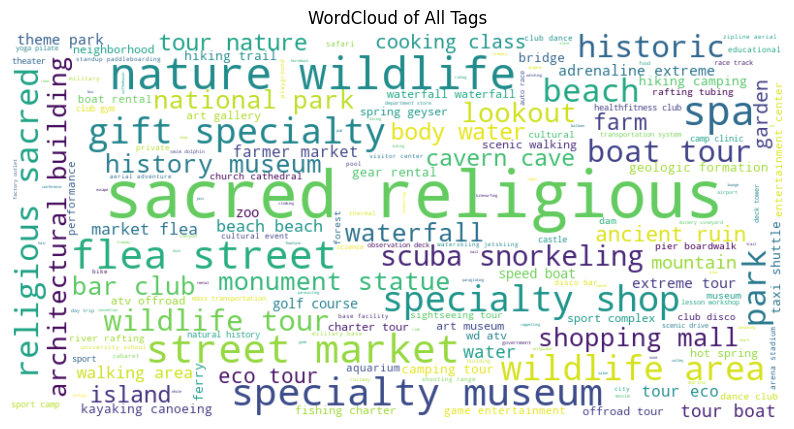

In [13]:
# รวมข้อความทั้งหมดจากคอลัมน์ 'tags'
all_text = " ".join(combined_details_df['tags'].fillna(''))

# สร้าง WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# แสดง WordCloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of All Tags")
plt.show()

## Experiment - [TF-IDF + LSA]

In [15]:
# ตรวจสอบและแทนค่าที่เป็น NaN ในคอลัมน์ 'tags'
combined_details_df['tags'] = combined_details_df['tags'].fillna('')
combined_details_df['tags'].replace("", "other", inplace=True)

# แปลงข้อความใน 'tags' ให้เป็นเมทริกซ์ TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(combined_details_df['tags'])


/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_55829/2129117024.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['tags'].replace("", "other", inplace=True)


In [16]:
def optimize_cluster_lsa(X, min_clusters=2, max_clusters=15, n_components_range=range(2, 20)):
    """
    Finds the optimal number of clusters (N_CLUSTER) for LSA-based clustering using 
    Elbow Method (Explained Variance), Silhouette Score, and Davies-Bouldin Index (DBI).
    
    Parameters:
    - X: TF-IDF matrix of text data
    - min_clusters: Minimum number of clusters to test (default: 2)
    - max_clusters: Maximum number of clusters to test (default: 15)
    - n_components_range: Range of n_components for LSA (default: 2-20)

    Returns:
    - best_n_cluster: Optimal number of clusters based on combined criteria
    """
    
    # Step 1: Find the best number of LSA components using Explained Variance (Elbow Method)
    explained_variance = []
    
    for n in n_components_range:
        svd = TruncatedSVD(n_components=n, random_state=42)
        svd.fit(X)
        explained_variance.append(np.sum(svd.explained_variance_ratio_))
    
    # Find Elbow Point (first major drop in variance)
    optimal_n_components = n_components_range[np.argmax(np.diff(explained_variance)) + 1]

    # Step 2: Apply LSA with optimal_n_components
    lsa = TruncatedSVD(n_components=optimal_n_components, random_state=42)
    lsa_embeddings = lsa.fit_transform(X)

    # Step 3: Find best N_CLUSTER using Silhouette Score and Davies-Bouldin Index
    silhouette_scores = []
    db_scores = []
    cluster_range = range(min_clusters, max_clusters + 1)

    for k in cluster_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(lsa_embeddings)

        silhouette_scores.append(silhouette_score(lsa_embeddings, labels))
        db_scores.append(davies_bouldin_score(lsa_embeddings, labels))

    # Find best cluster based on highest Silhouette Score and lowest DBI
    best_silhouette_k = cluster_range[np.argmax(silhouette_scores)]
    best_db_k = cluster_range[np.argmin(db_scores)]

    # Combine results: Take the average best cluster from all metrics
    best_n_cluster = int(np.round((best_silhouette_k + best_db_k) / 2))

    # Step 4: Plot results
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    # Plot Explained Variance (Elbow Method)
    ax[0].plot(n_components_range, explained_variance, marker="o", linestyle="-")
    ax[0].set_xlabel("Number of Components (n_components)")
    ax[0].set_ylabel("Explained Variance Ratio")
    ax[0].set_title("Elbow Method for Optimal LSA Components")
    ax[0].axvline(optimal_n_components, color="r", linestyle="--", label=f"Best: {optimal_n_components}")
    ax[0].legend()
    ax[0].grid()

    # Plot Silhouette Score
    ax[1].plot(cluster_range, silhouette_scores, marker="o", linestyle="-", color="g")
    ax[1].set_xlabel("Number of Clusters (k)")
    ax[1].set_ylabel("Silhouette Score")
    ax[1].set_title("Silhouette Score for Optimal Cluster Count")
    ax[1].axvline(best_silhouette_k, color="r", linestyle="--", label=f"Best: {best_silhouette_k}")
    ax[1].legend()
    ax[1].grid()

    # Plot Davies-Bouldin Index (DBI)
    ax[2].plot(cluster_range, db_scores, marker="o", linestyle="-", color="b")
    ax[2].set_xlabel("Number of Clusters (k)")
    ax[2].set_ylabel("Davies-Bouldin Score")
    ax[2].set_title("Davies-Bouldin Index for Optimal Cluster Count")
    ax[2].axvline(best_db_k, color="r", linestyle="--", label=f"Best: {best_db_k}")
    ax[2].legend()
    ax[2].grid()

    plt.show()

    print(f"🔹 Best number of LSA components: {optimal_n_components}")
    print(f"🔹 Best number of clusters based on Silhouette Score: {best_silhouette_k}")
    print(f"🔹 Best number of clusters based on Davies-Bouldin Index: {best_db_k}")
    print(f"✅ Final optimal number of clusters: {best_n_cluster}")

    return best_n_cluster

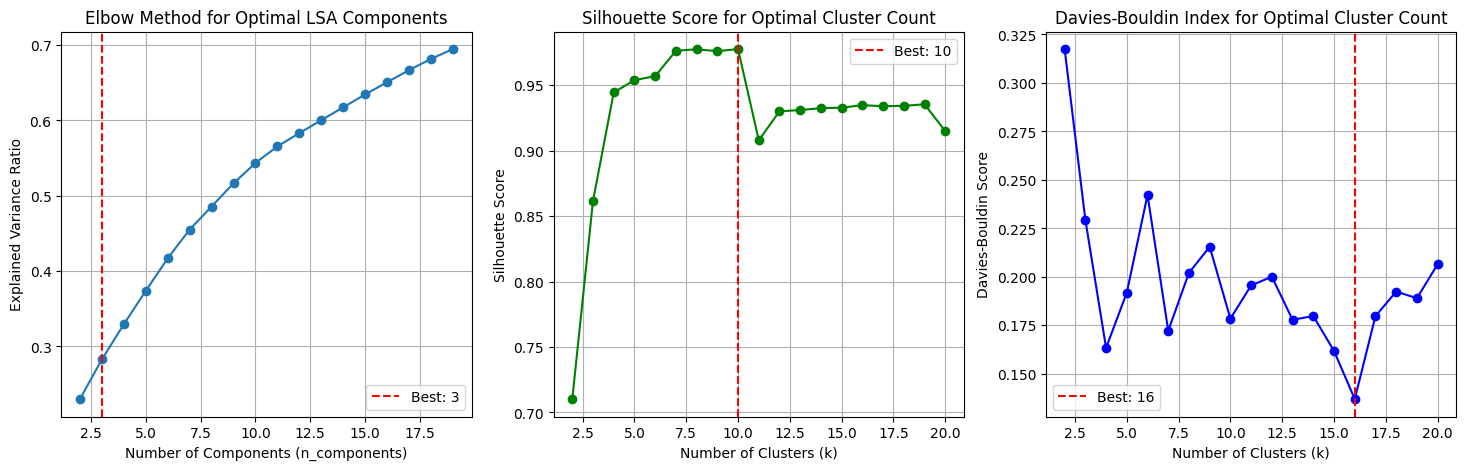

🔹 Best number of LSA components: 3
🔹 Best number of clusters based on Silhouette Score: 10
🔹 Best number of clusters based on Davies-Bouldin Index: 16
✅ Final optimal number of clusters: 13


In [17]:
N_CLUSTER = optimize_cluster_lsa(X, min_clusters=2, max_clusters=20, n_components_range=range(2, 20))

In [18]:
lsa_model = TruncatedSVD(n_components=N_CLUSTER, random_state=42)
lsa_model.fit(X)

TruncatedSVD(n_components=13, random_state=42)

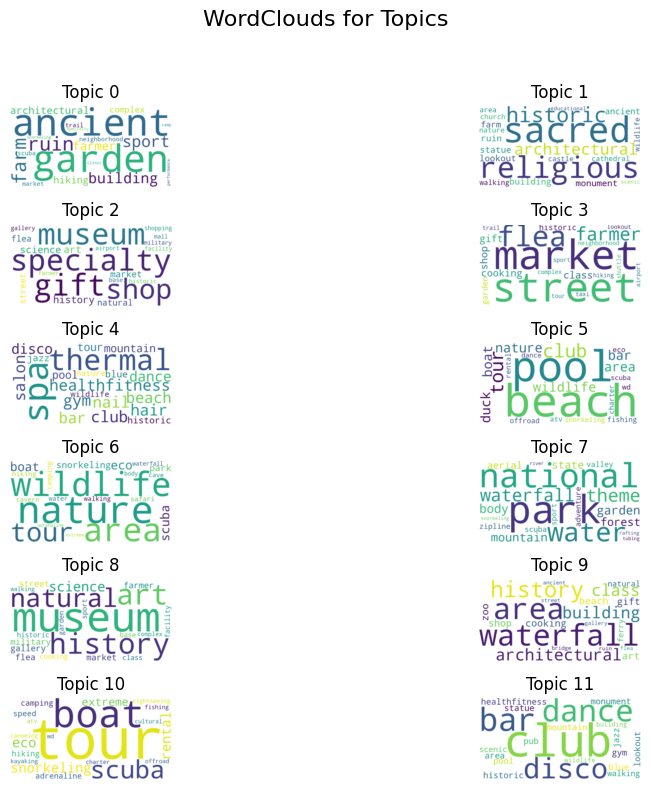

In [21]:
def get_topic_words(lsa_model, feature_names, n_top_words=10):
    topic_words = []
    for topic_idx, topic in enumerate(lsa_model.components_):
        words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topic_words.append(" ".join(words))
    return topic_words

# Generate topic words from LDA model
topic_words = get_topic_words(lsa_model, vectorizer.get_feature_names_out(), n_top_words=20)

# Function to plot WordClouds in a 2x2 grid
def plot_wordclouds_in_grid(topic_words, n_rows=2, n_cols=2):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
    fig.suptitle("WordClouds for Topics", fontsize=16)
    
    for idx, words in enumerate(topic_words):
        if idx < n_rows * n_cols:
            row, col = divmod(idx, n_cols)
            wordcloud = WordCloud(width=800, height=400, background_color='white').generate(words)
            axes[row, col].imshow(wordcloud, interpolation='bilinear')
            axes[row, col].axis('off')
            axes[row, col].set_title(f"Topic {idx}", fontsize=12)
        else:
            axes[row, col].axis('off')  # Turn off any extra axes
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to leave space for title
    plt.show()

# Plot the WordClouds in a 2x2 grid
plot_wordclouds_in_grid(topic_words, n_rows=round(N_CLUSTER/2), n_cols=2)

In [23]:
topic_words

['other garden ancient ruin farm sport building farmer architectural hiking complex neighborhood trail market scuba snorkeling specialty camp clinic performance',
 'sacred religious historic architectural building monument statue lookout ruin ancient farm walking area church cathedral castle wildlife nature educational scenic',
 'specialty museum gift shop history art science market natural street flea military shopping mall gallery airport farmer base facility historic',
 'market street flea farmer gift shop class cooking historic garden neighborhood sport hiking complex trail lookout airport shuttle taxi tour',
 'spa thermal healthfitness gym club hair nail salon beach bar dance disco pool tour mountain jazz blue historic wildlife nature',
 'beach pool club tour wildlife nature bar area boat duck fishing charter atv offroad wd rental eco snorkeling scuba dance',
 'nature wildlife area tour boat eco scuba snorkeling park hiking camping safari walking water cave cavern waterfall body a

In [24]:
combined_details_df['topic'] = lsa_model.transform(X).argmax(axis=1)

In [25]:
combined_details_df[['name', 'tags', 'topic']]

,name,tags,topic
0,House of Opium,history museum specialty museum,2
1,Opium Bar,bar club,11
2,Wat Phra That Doi Saket,sacred religious,1
3,Mae Ping River Cruise,boat tour,10
4,Pai River,body water,7
...,...,...,...
1761,Chao Lao Beach,beach,5
1762,Chao Lao Fish Bridge,bridge,12
1763,Wat Burapa Temple,sacred religious architectural building,1
1764,Kung Wiman Beach,beach,5


In [26]:
combined_details_df[['name', 'tags', 'topic']].to_parquet('output/lsa_clusters.parquet')